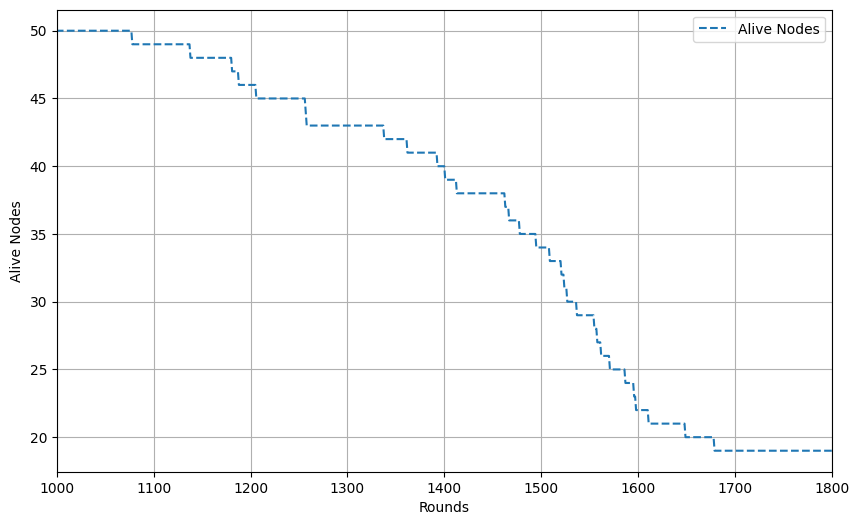

In [ ]:
# WSA Alive Nodes Shallow UWSN
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Constants
Eelec = 50e-9             # Electronics energy consumption per bit (J)
Eamp = 0.000013e-9        # Amplifier energy consumption (J)
Eda = 5e-9                # Energy for data aggregation (j)
packet_size = 800         # packet size (bits)
communication_range = 50 # Communication range (m)
Ts = 5                    # Maximum number of iterations for an individual whale
A = 0.5                   # Parameter for individual movement rule

# Underwater WSN Parameters

Pt = 70e-3               # Transmitter Power (W)
Pr = 16e-3               # Recieving Power   (W)
Bd = 4000                 # Bandwidth (Hz)

NL = 9.4371              # Noise Loss
TL = 61.5195             # Transmission Loss
DI = 0                   # Directive Index
SL = 159.19815           # Source Level

SNR = SL-NL-TL+DI        # Signal to Noise Ratio
h = 6.4301               # Bandwidth efficiency of modulation

# Function to calculate energy consumption for transmitting k bits of data
def energy_consumption(k, d):

        return (k *( Eelec + Eamp * d**4) + (Pt * k)/(Bd * h))


# Function to calculate energy consumption for receiving k bits of data
def receive_energy_consumption(k):

    return (k * (Eelec + Eda) + (Pr * k)/(Bd * h))


# Function to calculate fitness of a path
def fitness_function(path, nodes):
    total_energy_consumption = 0
    average_residual_energy = 0
    min_residual_energy = float('inf')

    path_length = len(path)

    for i in range(1, path_length):
        current_node = path[i]
        previous_node = path[i - 1]

        distance = math.sqrt((nodes[current_node][0] - nodes[previous_node][0]) ** 2 + (nodes[current_node][1] - nodes[previous_node][1]) ** 2  + (nodes[current_node][2] - nodes[previous_node][2]) ** 2)

        total_energy_consumption += energy_consumption(packet_size, distance)
        total_energy_consumption += receive_energy_consumption(packet_size)

        average_residual_energy += nodes[current_node][3]
        min_residual_energy = min(min_residual_energy, nodes[current_node][3])

    average_residual_energy /= (path_length - 1)
    fitness = (total_energy_consumption * path_length * 1) / (average_residual_energy * min_residual_energy * 1)

    return fitness

# Function to calculate the Levenshtein distance between two paths (whales)
def levenshtein_distance(path1, path2):
    n = len(path1)
    m = len(path2)
    dp = np.zeros((n + 1, m + 1), dtype=int)

    for i in range(n + 1):
        dp[i, 0] = i
    for j in range(m + 1):
        dp[0, j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if path1[i - 1] == path2[j - 1]:
                cost = 0
            else:
                cost = 1
            dp[i, j] = min(dp[i - 1, j] + 1, dp[i, j - 1] + 1, dp[i - 1, j - 1] + cost)
    return dp[n, m]

# Function to initialize whale individuals randomly
def initialize_whales(num_whales, source_node, nodes):
    whales = []

    for i in range(num_whales):
        path = [source_node]
        current_node = source_node
        while current_node != sink_node:
            neighbors = [node for node in range(num_nodes) if math.sqrt((nodes[node][0] - nodes[current_node][0]) ** 2 + (nodes[node][1] - nodes[current_node][1]) ** 2) <= communication_range and node not in path]
            if neighbors:
                next_node = random.choice(neighbors)
                path.append(next_node)
                current_node = next_node
            else:
                break
        whales.append(path)

    return whales

# Function to perform local search for a whale individual
def local_search(whale, nodes):
    path_length = len(whale)
    for i in range(1, path_length - 1):
        current_node = whale[i]
        neighbors = [node for node in range(num_nodes) if math.sqrt((nodes[node][0] - nodes[current_node][0]) ** 2 + (nodes[node][1] - nodes[current_node][1]) ** 2) <= communication_range and node not in whale]
        if neighbors:
            new_node = random.choice(neighbors)
            new_whale = whale.copy()
            new_whale[i] = new_node
            new_fitness = fitness_function(new_whale, nodes)
            current_fitness = fitness_function(whale, nodes)
            if new_fitness < current_fitness:
                whale = new_whale
    return whale

# Function to find the "better and nearest" whale individual for a given whale
def find_better_nearest_whale(whale, whales, nodes):
    min_distance = float('inf')
    better_whale = None
    for other_whale in whales:
        if fitness_function(other_whale, nodes) < fitness_function(whale, nodes) and other_whale != whale:
            distance = levenshtein_distance(whale, other_whale)
            if distance < min_distance:
                min_distance = distance
                better_whale = other_whale
    return better_whale

def update_position(whale, better_whale, nodes):
    new_whale = [whale[0]]
    current_node = whale[0]
    i = 1
    k = 1
    while current_node != sink_node:
        # Check if k is within the bounds of both lists before accessing elements
        if k < len(whale) and k < len(better_whale):
            if better_whale[k] not in new_whale and math.sqrt((nodes[better_whale[k]][0] - nodes[current_node][0]) ** 2 + (nodes[better_whale[k]][1] - nodes[current_node][1]) ** 2) <= communication_range:
                # Calculate energy consumption for this transition
                energy_cost = energy_consumption(packet_size, math.sqrt((nodes[better_whale[k]][0] - nodes[current_node][0]) ** 2 + (nodes[better_whale[k]][1] - nodes[current_node][1]) ** 2))

                # Select the next node based on the minimum energy consumption
                neighbors = [node for node in range(num_nodes) if math.sqrt((nodes[node][0] - nodes[current_node][0]) ** 2 + (nodes[node][1] - nodes[current_node][1]) ** 2) <= communication_range and node not in new_whale]
                if neighbors:
                    # Find the neighbor with the lowest energy cost
                    min_energy_neighbor = min(neighbors, key=lambda neighbor: energy_consumption(packet_size, math.sqrt((nodes[neighbor][0] - nodes[current_node][0]) ** 2 + (nodes[neighbor][1] - nodes[current_node][1]) ** 2)))

                    # Check if the energy cost of the "better and nearest" whale is lower
                    if energy_cost <= energy_consumption(packet_size, math.sqrt((nodes[min_energy_neighbor][0] - nodes[current_node][0]) ** 2 + (nodes[min_energy_neighbor][1] - nodes[current_node][1]) ** 2)) or random.random() < A:
                        new_whale.append(better_whale[k])
                        current_node = better_whale[k]
                    else:
                        new_whale.append(min_energy_neighbor)
                        current_node = min_energy_neighbor
                else:
                    break
                k += 1
            else:
                # Choose the next node based on the minimum energy cost
                neighbors = [node for node in range(num_nodes) if math.sqrt((nodes[node][0] - nodes[current_node][0]) ** 2 + (nodes[node][1] - nodes[current_node][1]) ** 2) <= communication_range and node not in new_whale]
                if neighbors:
                    min_energy_neighbor = min(neighbors, key=lambda neighbor: energy_consumption(packet_size, math.sqrt((nodes[neighbor][0] - nodes[current_node][0]) ** 2 + (nodes[neighbor][1] - nodes[current_node][1]) ** 2)))
                    new_whale.append(min_energy_neighbor)
                    current_node = min_energy_neighbor
                else:
                    break
                i += 1
                k += 1  # Continue incrementing k even if one list is exhausted
        else:
            # Choose the next node based on the minimum energy cost
            neighbors = [node for node in range(num_nodes) if math.sqrt((nodes[node][0] - nodes[current_node][0]) ** 2 + (nodes[node][1] - nodes[current_node][1]) ** 2) <= communication_range and node not in new_whale]
            if neighbors:
                min_energy_neighbor = min(neighbors, key=lambda neighbor: energy_consumption(packet_size, math.sqrt((nodes[neighbor][0] - nodes[current_node][0]) ** 2 + (nodes[neighbor][1] - nodes[current_node][1]) ** 2)))
                new_whale.append(min_energy_neighbor)
                current_node = min_energy_neighbor
            else:
                break
            i += 1
            k += 1 # Continue incrementing k even if one list is exhausted
    return new_whale


# WSA-ICR algorithm
def wsa_icr(num_whales, num_nodes, nodes, source_node, sink_node):
    whales = initialize_whales(num_whales, source_node, nodes)
    # Initialize a list to store counters for each whale
    whale_counters = [0] * num_whales
    best_fitness = float('inf')
    best_path = None
    for i in range(num_iterations):
        for j in range(num_whales):
            whale = whales[j]
            better_whale = find_better_nearest_whale(whale, whales, nodes)
            if better_whale:
                if whale_counters[j] != Ts:
                    whale_counters[j] += 1
                else:
                    new_whale = update_position(whale, better_whale, nodes)
                    new_fitness = fitness_function(new_whale, nodes)
                    if new_fitness < best_fitness:
                        best_fitness = new_fitness
                        best_path = new_whale
                    whale = local_search(whale, nodes)
                    fitness = fitness_function(whale, nodes)
                    if fitness < best_fitness:
                        best_fitness = fitness
                        best_path = whale
                    whale_counters[j] = 0
            else:
                if whale_counters[j] != Ts:
                    whale_counters[j] += 1
                else:
                    fitness = fitness_function(whale, nodes)
                    if fitness < best_fitness:
                        best_fitness = fitness
                        best_path = whale
                    whale = local_search(whale, nodes)
                    fitness = fitness_function(whale, nodes)
                    if fitness < best_fitness:
                        best_fitness = fitness
                        best_path = whale
                    whale_counters[j] = 0

    return best_path, best_fitness



def Network_Lifetime(num_whales, num_nodes, nodes, source_node, sink_node, num_rounds):
    # Initialize energy monitoring variables
    first_node_dead_round = None
    half_node_dead_round = None
    last_node_dead_round = None
    alive_nodes = [num_nodes]
    half_nodes = num_nodes // 2

    for round_counter in range(num_rounds):
        # Run a single round of WSA-ICR
        whales = initialize_whales(num_whales, source_node, nodes)
        whale_counters = [0] * num_whales
        best_fitness = float('inf')
        best_path = None

        for i in range(num_whales):
            whale = whales[i]
            if whale_counters[i] < Ts:
                whales[i] = local_search(whale, nodes)
                whale_counters[i] += 1
            else:
                better_whale = find_better_nearest_whale(whale, whales, nodes)
                if better_whale is not None:
                    whales[i] = update_position(whale, better_whale, nodes)
                whale_counters[i] = 0

            fitness = fitness_function(whales[i], nodes)
            if fitness < best_fitness:
                best_fitness = fitness
                best_path = whales[i]

        # Simulate energy consumption for the best path
        for i in range(1, len(best_path)):
            current_node = best_path[i]
            previous_node = best_path[i - 1]

            distance = math.sqrt((nodes[current_node][0] - nodes[previous_node][0]) ** 2 + (nodes[current_node][1] - nodes[previous_node][1]) ** 2+ (nodes[current_node][2] - nodes[previous_node][2]) ** 2)
            energy_cost = energy_consumption(packet_size, distance) + receive_energy_consumption(packet_size)

            nodes[current_node] = (nodes[current_node][0], nodes[current_node][1], nodes[current_node][2], nodes[current_node][3] - energy_cost)

            if nodes[current_node]==0:
              nodes[current_node][3] = 0

        # Energy monitoring
        dead_nodes =0
        for node in nodes:
          if node[3] <= 0:
            dead_nodes += 1

        if first_node_dead_round is None and dead_nodes > 0:
            first_node_dead_round = round_counter

        if half_node_dead_round is None and dead_nodes == half_nodes:
            half_node_dead_round = round_counter

        if last_node_dead_round is None and dead_nodes == num_nodes-1:
            last_node_dead_round = round_counter
            break

        # Update the number of alive nodes for the current round
        alive_nodes.append(num_nodes - dead_nodes)

    if last_node_dead_round is None:
        last_node_dead_round = num_rounds

    return first_node_dead_round, half_node_dead_round, last_node_dead_round, alive_nodes


# Generate random sensor nodes in 200 x 200 area
num_nodes = 50
nodes = []

for i in range(num_nodes):
    x = random.uniform(0, 200)              # X coordinate
    y = random.uniform(0, 200)              # Y coordinate
    z = random.uniform(0, 200)              # Z coordinate
    initial_energy = 1                      # Set Initial Energy (Joules)
    nodes.append([x, y,z, initial_energy])

num_whales = 10
num_iterations = 100

source_node = 0
sink_node = num_nodes - 1

#Set the maximum number of rounds
num_rounds = 1800

FND, HND, LND, alive_nodes = Network_Lifetime(10, num_nodes, nodes, source_node, sink_node, num_rounds)

# Plot the number of alive nodes vs rounds
plt.figure(figsize=(10,6))
plt.plot(range(num_rounds + 1), alive_nodes, label='Alive Nodes',linestyle='dashed')
plt.xlabel('Rounds')
plt.ylabel('Alive Nodes')
plt.xlim(1000,1800)
plt.legend()
plt.grid(True)
plt.show()